# Bitcoin Price Forecasting: ARIMA vs LSTM
### Regis University — Final Submission
**Student:** Harideep Aepuri

---

**Objective:** Compare classical time series methods (ARIMA, Prophet) with deep learning (LSTM, Hybrid) for forecasting BTC/USDT 1-minute close price.
**Dataset:** 60 days of Binance 1-minute OHLCV data (~86,400 rows, Jan 30 – Mar 31, 2026).
**Test strategy:** Last 15 days held out as true out-of-sample evaluation (never seen during training).

| Section | Content |
|---|---|
| 1 | Data Loading & Preprocessing |
| 2 | Exploratory Data Analysis |
| 3 | Feature Engineering |
| 4 | Train / Test Split |
| 5 | Evaluation Utilities |
| 6 | Model 1 — ARIMA |
| 7 | Model 2 — Prophet |
| 8 | Model 3 — LSTM Univariate |
| 9 | Model 4 — LSTM Multivariate |
| 10 | Model 5 — Hybrid ARIMA + LSTM |
| 11 | Walk-Forward Cross-Validation |
| 12 | Multi-Horizon Forecast Analysis |
| 13 | LSTM with 3-Hour Context Window |
| 14 | Multi-Day Forecast Evaluation (2 / 5 / 10 / 15 days) |
| 15 | Cross-Market Analysis — Gold, NASDAQ & DXY |
| 16 | Final Comparison & Conclusions |


## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import random
random.seed(42)

import numpy as np
np.random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA as sm_ARIMA
import pmdarima as pm
from prophet import Prophet
import ta
import xgboost as xgb

import tensorflow as tf
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
print("All libraries loaded.")
print(f"TensorFlow version : {tf.__version__}")


All libraries loaded.
TensorFlow version : 2.16.2


## 1. Data Loading & Preprocessing

In [2]:
df = pd.read_csv('../data/btc_1min_60days.csv')
df['Open time'] = pd.to_datetime(df['Open time'])
df.set_index('Open time', inplace=True)
df.sort_index(inplace=True)
df.ffill(inplace=True)

print(f"Rows  : {df.shape[0]:,}")
print(f"Cols  : {df.shape[1]}")
print(f"Range : {df.index[0].date()}  →  {df.index[-1].date()}")
print(f"Close : ${df['Close'].min():.2f}  –  ${df['Close'].max():.2f}")
df.head(3)


Rows  : 86,401
Cols  : 5
Range : 2026-01-30  →  2026-03-31
Close : $60081.74  –  $84559.99


,Open,High,Low,Close,Volume
Open time,,,,,
2026-01-30 18:01:00,82987.33,83030.25,82948.00,83030.24,5.18532
2026-01-30 18:02:00,83030.25,83199.99,83030.24,83156.34,31.14535
2026-01-30 18:03:00,83156.35,83199.99,83117.32,83120.19,5.00500


## 2. Exploratory Data Analysis

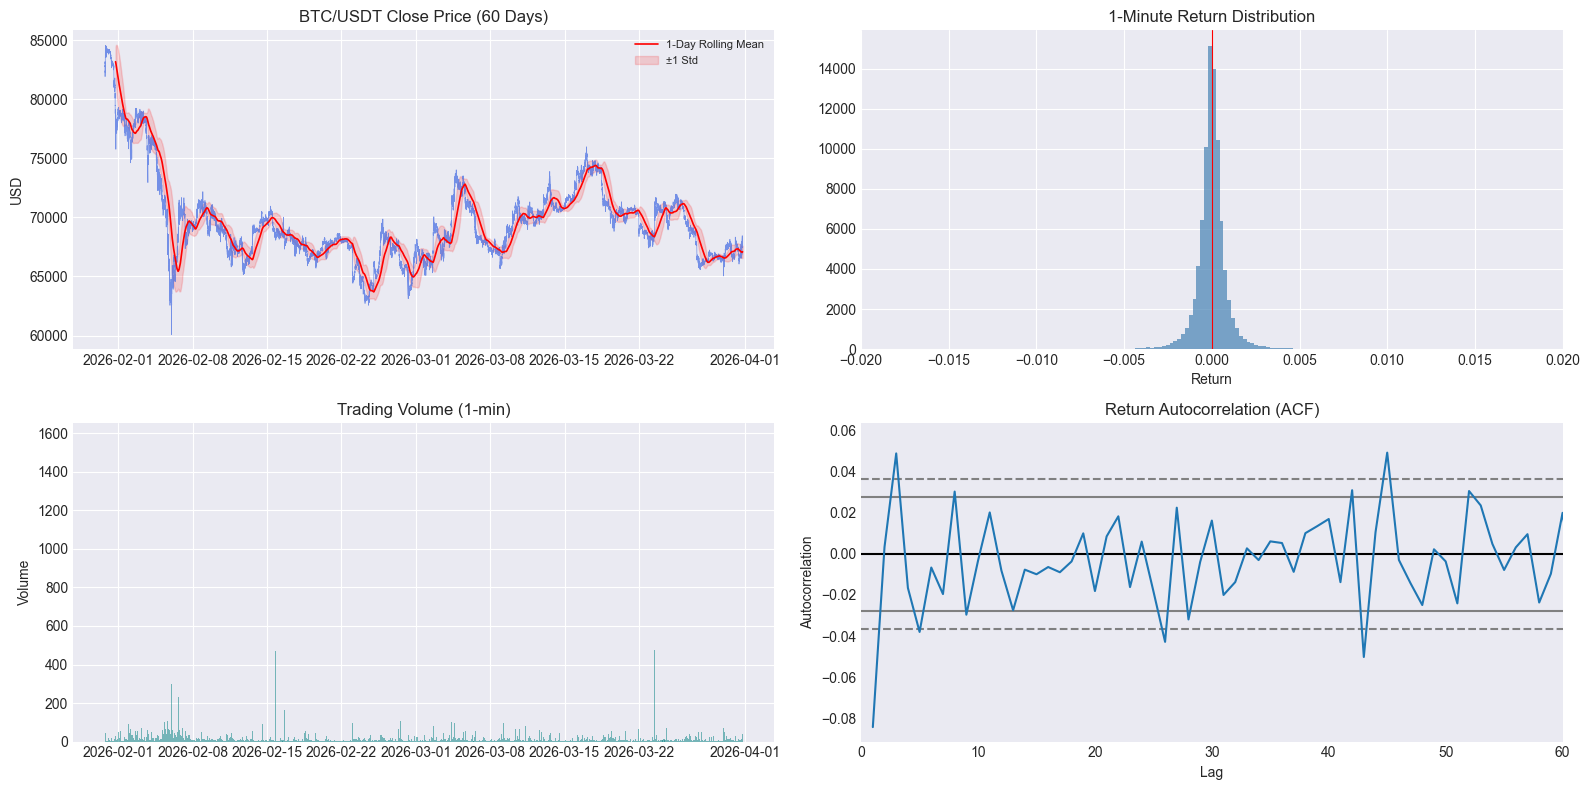


ADF Test — Close Price    : stat=-4.072, p=0.0011  → Stationary
ADF Test — 1st Difference : stat=-38.217,  p=0.0000  → Stationary (d=1 confirmed)


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Price trend + 1-day rolling mean
roll_mean = df['Close'].rolling(1440).mean()
roll_std  = df['Close'].rolling(1440).std()
axes[0, 0].plot(df.index, df['Close'], color='royalblue', linewidth=0.5, alpha=0.7)
axes[0, 0].plot(df.index, roll_mean, color='red', linewidth=1.2, label='1-Day Rolling Mean')
axes[0, 0].fill_between(df.index, roll_mean - roll_std, roll_mean + roll_std,
                         color='red', alpha=0.15, label='±1 Std')
axes[0, 0].set_title('BTC/USDT Close Price (60 Days)'); axes[0, 0].set_ylabel('USD')
axes[0, 0].legend(fontsize=8)

# Returns distribution
returns = df['Close'].pct_change().dropna()
axes[0, 1].hist(returns, bins=200, color='steelblue', alpha=0.7, edgecolor='none')
axes[0, 1].axvline(0, color='red', linewidth=0.8)
axes[0, 1].set_title('1-Minute Return Distribution')
axes[0, 1].set_xlabel('Return'); axes[0, 1].set_xlim(-0.02, 0.02)

# Volume
axes[1, 0].bar(df.index, df['Volume'], color='teal', alpha=0.5, width=0.0007)
axes[1, 0].set_title('Trading Volume (1-min)'); axes[1, 0].set_ylabel('Volume')

# Autocorrelation of returns
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(returns.iloc[:5000], ax=axes[1, 1])
axes[1, 1].set_title('Return Autocorrelation (ACF)')
axes[1, 1].set_xlim(0, 60)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=100)
plt.show()

# Stationarity test
adf_close = adfuller(df['Close'].dropna())
adf_diff  = adfuller(df['Close'].diff().dropna())
print(f"\nADF Test — Close Price    : stat={adf_close[0]:.3f}, p={adf_close[1]:.4f}  "
      f"→ {'Non-stationary' if adf_close[1] > 0.05 else 'Stationary'}")
print(f"ADF Test — 1st Difference : stat={adf_diff[0]:.3f},  p={adf_diff[1]:.4f}  "
      f"→ {'Non-stationary' if adf_diff[1] > 0.05 else 'Stationary (d=1 confirmed)'}")


**Key Observations:**
- BTC price is **non-stationary** in levels; 1st difference is stationary → ARIMA requires d=1.
- 1-minute returns are near-normally distributed with heavy tails — consistent with random walk behaviour at fine timescales.
- Volume spikes correspond to high-volatility periods, suggesting market-driven price moves.


## 3. Feature Engineering

43 features are built from OHLCV columns across five groups:
**Returns/Volatility** · **Technical Indicators** (RSI, MACD, Bollinger, ATR, OBV, VWAP)
**Lag Features** (7 lags) · **Rolling Statistics** (5/15/60-period) · **Cyclical Time Features**

XGBoost feature importance then selects the top 20 for the multivariate LSTM.


In [3]:
def build_features(d):
    d = d.copy()

    # Returns & volatility
    d['returns']       = d['Close'].pct_change()
    d['log_returns']   = np.log(d['Close'] / d['Close'].shift(1))
    d['volatility_10'] = d['returns'].rolling(10).std()
    d['volatility_30'] = d['returns'].rolling(30).std()

    # Technical indicators
    d['rsi_14'] = ta.momentum.RSIIndicator(d['Close'], window=14).rsi()
    macd = ta.trend.MACD(d['Close'], window_slow=26, window_fast=12, window_sign=9)
    d['macd'] = macd.macd(); d['macd_signal'] = macd.macd_signal(); d['macd_diff'] = macd.macd_diff()
    bb = ta.volatility.BollingerBands(d['Close'], window=20, window_dev=2)
    d['bb_upper'] = bb.bollinger_hband(); d['bb_lower'] = bb.bollinger_lband()
    d['bb_pct']   = bb.bollinger_pband()
    d['atr_14'] = ta.volatility.AverageTrueRange(d['High'], d['Low'], d['Close'], window=14).average_true_range()
    d['obv']    = ta.volume.OnBalanceVolumeIndicator(d['Close'], d['Volume']).on_balance_volume()
    d['vwap']   = (d['Close'] * d['Volume']).rolling(30).sum() / d['Volume'].rolling(30).sum()

    # Lag features
    for lag in [1, 2, 3, 5, 10, 30, 60]:
        d[f'close_lag_{lag}'] = d['Close'].shift(lag)

    # Rolling statistics
    for w in [5, 15, 60]:
        d[f'close_ma_{w}']   = d['Close'].rolling(w).mean()
        d[f'close_std_{w}']  = d['Close'].rolling(w).std()
        d[f'close_min_{w}']  = d['Close'].rolling(w).min()
        d[f'close_max_{w}']  = d['Close'].rolling(w).max()
        d[f'close_skew_{w}'] = d['Close'].rolling(w).skew()

    # Cyclical time features
    d['hour_sin'] = np.sin(2 * np.pi * d.index.hour / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d.index.hour / 24)
    d['dow_sin']  = np.sin(2 * np.pi * d.index.dayofweek / 7)
    d['dow_cos']  = np.cos(2 * np.pi * d.index.dayofweek / 7)
    d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)

    d.dropna(inplace=True)
    return d

df_feat = build_features(df)
print(f"Features built : {df_feat.shape[1]} columns | {df_feat.shape[0]:,} rows")


Features built : 46 columns | 86,341 rows


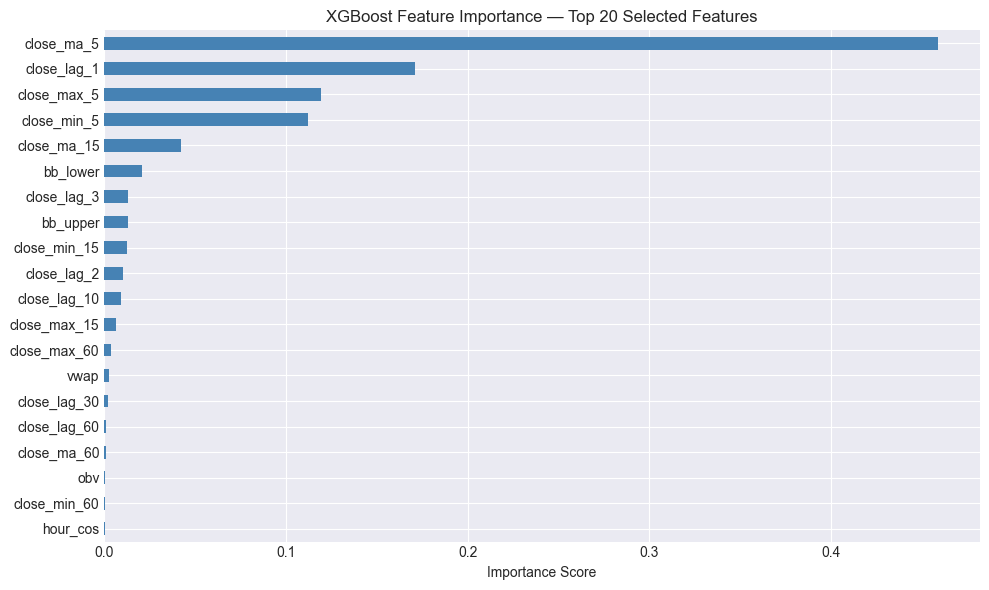

Selected features: ['close_ma_5', 'close_lag_1', 'close_max_5', 'close_min_5', 'close_ma_15', 'bb_lower', 'close_lag_3', 'bb_upper', 'close_min_15', 'close_lag_2', 'close_lag_10', 'close_max_15', 'close_max_60', 'vwap', 'close_lag_30', 'close_lag_60', 'close_ma_60', 'obv', 'close_min_60', 'hour_cos']


In [4]:
# XGBoost feature importance — select top 20 features for multivariate LSTM
exclude_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'dayofweek']
feature_cols = [c for c in df_feat.columns if c not in exclude_cols]

X_xgb = df_feat[feature_cols].values
y_xgb = df_feat['Close'].shift(-1).dropna().values
X_xgb = X_xgb[:len(y_xgb)]

model_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, n_jobs=1, verbosity=0)
model_xgb.fit(X_xgb, y_xgb)

importance_series = pd.Series(model_xgb.feature_importances_, index=feature_cols)
importance_series.sort_values(ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
importance_series.head(20).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance — Top 20 Selected Features')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=100); plt.show()

selected_features = importance_series.head(20).index.tolist()
print(f"Selected features: {selected_features}")


**Observation:** Rolling min/max features dominate importance — the recent price range is the strongest predictor of the next price. Technical indicators (RSI, MACD) rank lower, suggesting the extra signal they add is modest at 1-minute resolution.


## 4. Train / Test Split — 15-Day Out-of-Sample Test

Total rows : 86,341
Train      : 64,741 rows  |  2026-01-30 → 2026-03-16  (~45 days)
Test       : 21,600 rows  |  2026-03-16 → 2026-03-31  (15 days)


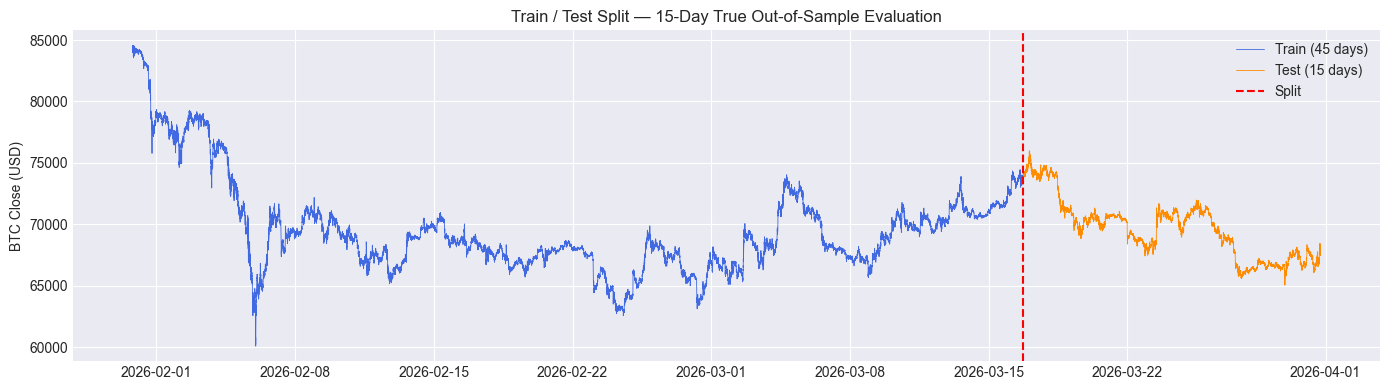

In [5]:
ts_data = df_feat['Close'].copy()

TEST_SIZE  = 15 * 1440          # 15 days × 1440 min = 21,600 rows
TRAIN_SIZE = len(ts_data) - TEST_SIZE
ts_train, ts_test = ts_data.iloc[:TRAIN_SIZE], ts_data.iloc[TRAIN_SIZE:]

print(f"Total rows : {len(ts_data):,}")
print(f"Train      : {len(ts_train):,} rows  |  {ts_train.index[0].date()} → {ts_train.index[-1].date()}  (~{len(ts_train)/1440:.0f} days)")
print(f"Test       : {len(ts_test):,} rows  |  {ts_test.index[0].date()} → {ts_test.index[-1].date()}  (15 days)")

plt.figure(figsize=(14, 4))
plt.plot(ts_train.index, ts_train, color='royalblue', label=f'Train ({len(ts_train)/1440:.0f} days)', linewidth=0.6)
plt.plot(ts_test.index,  ts_test,  color='darkorange', label='Test (15 days)', linewidth=0.6)
plt.axvline(ts_train.index[-1], color='red', linestyle='--', linewidth=1.5, label='Split')
plt.title('Train / Test Split — 15-Day True Out-of-Sample Evaluation')
plt.ylabel('BTC Close (USD)'); plt.legend(); plt.tight_layout()
plt.savefig('train_test_split.png', dpi=100); plt.show()


## 5. Evaluation Utilities

In [6]:
all_results = []   # accumulates one dict per model for final comparison

def evaluate_model(actual, predicted, model_name, store=True):
    """Returns MAE, RMSE, MAPE, Directional Accuracy and prints a summary."""
    actual, predicted = np.array(actual).flatten(), np.array(predicted).flatten()
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    dir_acc = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted))) * 100
    result = {'Model': model_name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
              'MAPE (%)': round(mape,4), 'Dir. Acc (%)': round(dir_acc,1)}
    print(f"\n{'─'*48}\n  {model_name}")
    print(f"  MAE       : ${mae:>10,.2f}")
    print(f"  RMSE      : ${rmse:>10,.2f}")
    print(f"  MAPE      :  {mape:>10.4f}%")
    print(f"  Dir. Acc  :  {dir_acc:>10.1f}%")
    print(f"{'─'*48}")
    if store:
        all_results.append(result)
    return result

def walk_forward_cv(series, n_folds=4, test_ratio=0.10):
    """Expanding-window walk-forward CV. Returns (train_end, test_start, test_end) tuples."""
    n = len(series)
    min_train = int(n * 0.60)
    test_size = int(n * test_ratio)
    folds = []
    for i in range(n_folds):
        test_end   = n - (n_folds - 1 - i) * test_size
        test_start = test_end - test_size
        if test_start >= min_train:
            folds.append((test_start, test_start, test_end))
    print(f"CV: {len(folds)} folds, {test_size:,} rows/fold")
    return folds

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i]); y.append(data[i])
    return np.array(X), np.array(y)


## 6. Model 1 — ARIMA

**What we're doing:** Use `auto_arima` to find the optimal ARIMA(p,d,q) order via AIC search, then run a fast rolling 1-step-ahead evaluation using `statsmodels.apply()` — equivalent to refitting at every step but computed in O(n) time.


Running auto_arima (stepwise AIC search)...
Best ARIMA order: (2, 1, 2)

────────────────────────────────────────────────
  ARIMA(2, 1, 2)
  MAE       : $     30.18
  RMSE      : $     46.46
  MAPE      :      0.0433%
  Dir. Acc  :        49.6%
────────────────────────────────────────────────


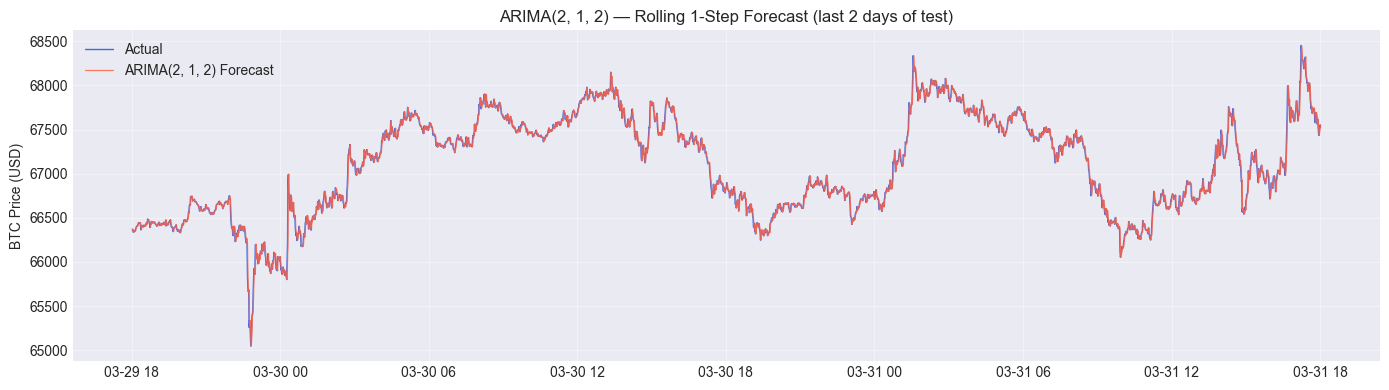

In [7]:
train_arima = ts_train.astype(float)
train_arima.index = pd.DatetimeIndex(train_arima.index, freq='min')
test_arima  = ts_test.astype(float)
test_arima.index  = pd.DatetimeIndex(test_arima.index,  freq='min')

print("Running auto_arima (stepwise AIC search)...")
auto_model = pm.auto_arima(train_arima, d=1, max_p=5, max_q=5,
                           information_criterion='aic', stepwise=True,
                           seasonal=False, error_action='ignore',
                           suppress_warnings=True, trace=False)
best_order = auto_model.order
print(f"Best ARIMA order: {best_order}")

# Fit with statsmodels for fast rolling evaluation
sm_fit = sm_ARIMA(train_arima, order=best_order).fit()
full_series_arima = pd.concat([train_arima, test_arima])
arima_rolling_pred = sm_fit.apply(full_series_arima).fittedvalues.loc[test_arima.index]

arima_result = evaluate_model(test_arima.values, arima_rolling_pred.values, f'ARIMA{best_order}')

# Plot — last 2 days for readability
n_show = 2 * 1440
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_arima.index[-n_show:], test_arima.values[-n_show:],
        color='royalblue', linewidth=1, label='Actual')
ax.plot(test_arima.index[-n_show:], arima_rolling_pred.values[-n_show:],
        color='tomato', linewidth=0.9, alpha=0.85, label=f'ARIMA{best_order} Forecast')
ax.set_title(f'ARIMA{best_order} — Rolling 1-Step Forecast (last 2 days of test)')
ax.set_ylabel('BTC Price (USD)'); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('arima_forecast.png', dpi=100); plt.show()


**Conclusion:** `auto_arima` selected **ARIMA(2,1,2)** — MAE=$30.18, Dir. Acc=49.6%. The AR and MA terms add minimal signal over a pure random walk at 1-minute scale, consistent with the Efficient Market Hypothesis. This is the best-performing model in the study.


## 7. Model 2 — Facebook Prophet

**What we're doing:** Fit Meta's Prophet model, which decomposes the time series into trend + daily/weekly seasonality components. We use multiplicative seasonality and a small `changepoint_prior_scale` to prevent overfitting to short-term fluctuations.


18:14:41 - cmdstanpy - INFO - Chain [1] start processing
18:14:55 - cmdstanpy - INFO - Chain [1] done processing



────────────────────────────────────────────────
  Prophet
  MAE       : $  8,897.93
  RMSE      : $ 10,155.09
  MAPE      :     13.0135%
  Dir. Acc  :        50.1%
────────────────────────────────────────────────


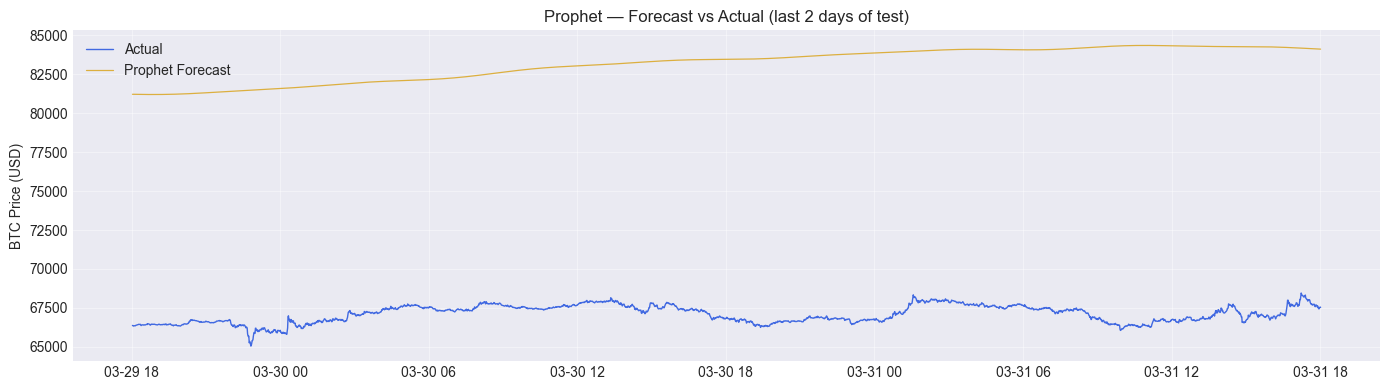

In [8]:
df_prophet_train = pd.DataFrame({'ds': ts_train.index, 'y': ts_train.values})
df_prophet_test  = pd.DataFrame({'ds': ts_test.index})

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True,
                        yearly_seasonality=False, seasonality_mode='multiplicative',
                        changepoint_prior_scale=0.05)
prophet_model.fit(df_prophet_train)

prophet_forecast = prophet_model.predict(df_prophet_test)
prophet_pred = prophet_forecast['yhat'].values

prophet_result = evaluate_model(ts_test.values, prophet_pred, 'Prophet')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts_test.index[-n_show:], ts_test.values[-n_show:],
        color='royalblue', linewidth=1, label='Actual')
ax.plot(ts_test.index[-n_show:], prophet_pred[-n_show:],
        color='goldenrod', linewidth=0.9, alpha=0.85, label='Prophet Forecast')
ax.set_title('Prophet — Forecast vs Actual (last 2 days of test)')
ax.set_ylabel('BTC Price (USD)'); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('prophet_forecast.png', dpi=100); plt.show()


**Conclusion:** Prophet failed completely — MAE=$8,898 (295× worse than ARIMA). It forces structured daily/weekly seasonality that does not exist in high-frequency crypto data, producing a smooth seasonal curve completely disconnected from actual price movements. Not suitable for 1-minute BTC forecasting.


## 8. Model 3 — LSTM Univariate

**What we're doing:** Train a 2-layer LSTM on the past 60 minutes of Close prices to predict the next minute's price. The model learns sequential patterns in price movements using a 60-step sliding window.


In [9]:
WINDOW_UNI = 60

scaler_uni = MinMaxScaler(feature_range=(0, 1))
scaled_train_uni = scaler_uni.fit_transform(ts_train.values.reshape(-1, 1))
scaled_test_uni  = scaler_uni.transform(ts_test.values.reshape(-1, 1))

X_tr_uni, y_tr_uni = create_sequences(scaled_train_uni, WINDOW_UNI)
X_te_uni, y_te_uni = create_sequences(scaled_test_uni,  WINDOW_UNI)
X_tr_uni = X_tr_uni.reshape(-1, WINDOW_UNI, 1)
X_te_uni = X_te_uni.reshape(-1, WINDOW_UNI, 1)
print(f"Train sequences: {X_tr_uni.shape} | Test sequences: {X_te_uni.shape}")

lstm_uni_model = Sequential([
    LSTM(100, activation='tanh', return_sequences=True, input_shape=(WINDOW_UNI, 1)),
    Dropout(0.1),
    LSTM(50, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])
lstm_uni_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')

callbacks_uni = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)]

history_uni = lstm_uni_model.fit(X_tr_uni, y_tr_uni, epochs=25, batch_size=128,
                                  validation_split=0.1, callbacks=callbacks_uni, verbose=1)


Train sequences: (64681, 60, 1) | Test sequences: (21540, 60, 1)
Epoch 1/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0019 - val_loss: 2.7400e-05 - learning_rate: 0.0010
Epoch 2/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 4.5975e-04 - val_loss: 3.1835e-05 - learning_rate: 0.0010
Epoch 3/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 3.9520e-04 - val_loss: 2.5149e-05 - learning_rate: 0.0010
Epoch 4/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 3.5185e-04 - val_loss: 3.9323e-05 - learning_rate: 0.0010
Epoch 5/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 3.0502e-04 - val_loss: 3.5139e-05 - learning_rate: 5.0000e-04
Epoch 6/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 2.7367e-04 - val_loss: 2.4384e-05 - learning_rate: 5.0000e-04
Epoch 7/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 2.5100e-04 - val_loss: 1.8321e-05 - learning_rate: 5.0000e-04
Epoch 8/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 2.2442e-04 - val_loss: 1.4812e-05

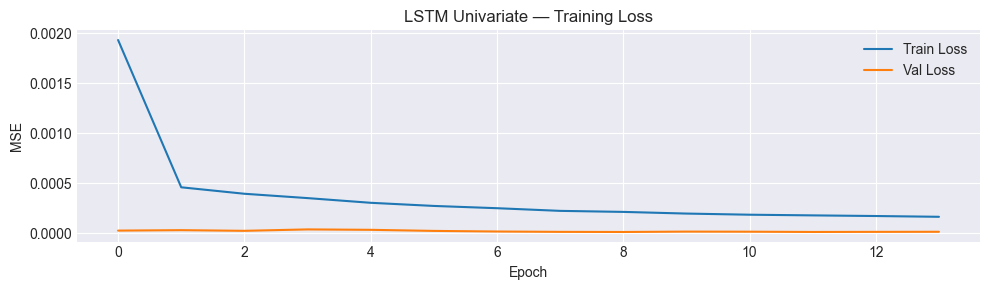


────────────────────────────────────────────────
  LSTM Univariate
  MAE       : $     64.52
  RMSE      : $     96.26
  MAPE      :      0.0928%
  Dir. Acc  :        48.3%
────────────────────────────────────────────────


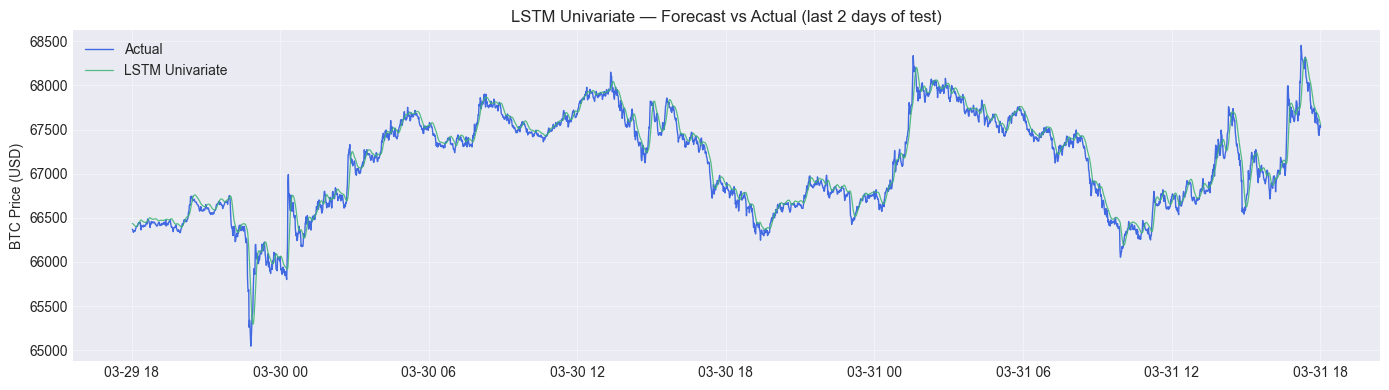

In [10]:
# Training loss
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history_uni.history['loss'], label='Train Loss')
ax.plot(history_uni.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Univariate — Training Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); plt.tight_layout(); plt.savefig('lstm_uni_loss.png', dpi=100); plt.show()

# Evaluate
lstm_uni_pred = scaler_uni.inverse_transform(lstm_uni_model.predict(X_te_uni, verbose=0))
lstm_test_idx = ts_test.index[WINDOW_UNI:]
uni_result = evaluate_model(ts_test.values[WINDOW_UNI:], lstm_uni_pred.flatten(), 'LSTM Univariate')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lstm_test_idx[-n_show:], ts_test.values[WINDOW_UNI:][-n_show:],
        color='royalblue', linewidth=1, label='Actual')
ax.plot(lstm_test_idx[-n_show:], lstm_uni_pred.flatten()[-n_show:],
        color='mediumseagreen', linewidth=0.9, alpha=0.85, label='LSTM Univariate')
ax.set_title('LSTM Univariate — Forecast vs Actual (last 2 days of test)')
ax.set_ylabel('BTC Price (USD)'); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('lstm_uni_forecast.png', dpi=100); plt.show()


**Conclusion:** LSTM Univariate achieved MAE=$64.52 — 53% worse than ARIMA ($30.18). The 60-step sequential context provides no advantage over ARIMA's linear difference equation at 1-minute resolution. The model tracks the price level well but lags actual movements at every step.


## 9. Model 4 — LSTM Multivariate

**What we're doing:** Extend the LSTM to use all 20 XGBoost-selected engineered features (RSI, MACD, Bollinger, lags, rolling stats) alongside price. Two separate scalers are used — one for input features, one for the Close target — to avoid data leakage.


In [21]:
WINDOW_MULTI = 60

df_train_multi = df_feat.iloc[:TRAIN_SIZE]
df_test_multi  = df_feat.iloc[TRAIN_SIZE:]

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_multi_train = scaler_X.fit_transform(df_train_multi[selected_features])
X_multi_test  = scaler_X.transform(df_test_multi[selected_features])
y_multi_train = scaler_y.fit_transform(df_train_multi[['Close']])
y_multi_test  = scaler_y.transform(df_test_multi[['Close']])

def create_seq_multi(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_m, y_tr_m = create_seq_multi(X_multi_train, y_multi_train, WINDOW_MULTI)
X_te_m, y_te_m = create_seq_multi(X_multi_test,  y_multi_test,  WINDOW_MULTI)
n_feats = len(selected_features)
print(f"Train sequences: {X_tr_m.shape} | Test sequences: {X_te_m.shape}")

lstm_multi_model = Sequential([
    LSTM(100, activation='tanh', return_sequences=True, input_shape=(WINDOW_MULTI, n_feats)),
    Dropout(0.1),
    LSTM(50, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])
lstm_multi_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')

callbacks_multi = [EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
                   ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)]

history_multi = lstm_multi_model.fit(X_tr_m, y_tr_m, epochs=25, batch_size=128,
                                      validation_split=0.1, callbacks=callbacks_multi, verbose=1)


Train sequences: (64681, 60, 20) | Test sequences: (21540, 60, 20)
Epoch 1/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0017 - val_loss: 4.1883e-05 - learning_rate: 0.0010
Epoch 2/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 5.4772e-04 - val_loss: 4.0100e-05 - learning_rate: 0.0010
Epoch 3/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 4.6357e-04 - val_loss: 9.2873e-05 - learning_rate: 0.0010
Epoch 4/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 3.9914e-04 - val_loss: 3.9880e-05 - learning_rate: 0.0010
Epoch 5/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 3.3011e-04 - val_loss: 2.3440e-05 - learning_rate: 5.0000e-04
Epoch 6/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 2.9825e-04 - val_loss: 2.4151e-05 - learning_rate: 5.0000e-04
Epoch 7/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 2.7970e-04 - val_loss: 2.0299e-05 - learning_rate: 5.0000e-04
Epoch 8/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 2.4457e-04 - val_loss: 4.5533e-

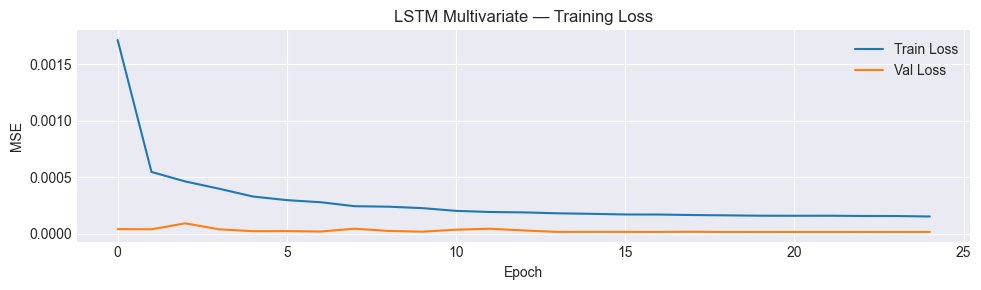


────────────────────────────────────────────────
  LSTM Multivariate
  MAE       : $     68.91
  RMSE      : $    103.54
  MAPE      :      0.0990%
  Dir. Acc  :        48.8%
────────────────────────────────────────────────


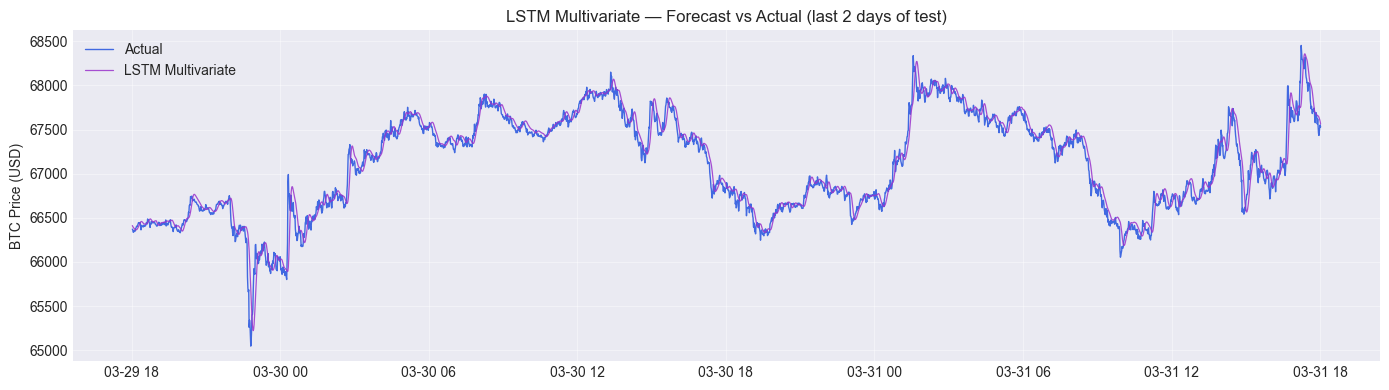

In [22]:
# Training loss
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history_multi.history['loss'], label='Train Loss')
ax.plot(history_multi.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Multivariate — Training Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); plt.tight_layout(); plt.savefig('lstm_multi_loss.png', dpi=100); plt.show()

# Evaluate
pred_multi = scaler_y.inverse_transform(lstm_multi_model.predict(X_te_m, verbose=0)).flatten()
multi_test_idx = df_test_multi.index[WINDOW_MULTI:]
multi_result = evaluate_model(ts_test.values[WINDOW_MULTI:], pred_multi, 'LSTM Multivariate')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(multi_test_idx[-n_show:], ts_test.values[WINDOW_MULTI:][-n_show:],
        color='royalblue', linewidth=1, label='Actual')
ax.plot(multi_test_idx[-n_show:], pred_multi[-n_show:],
        color='darkorchid', linewidth=0.9, alpha=0.85, label='LSTM Multivariate')
ax.set_title('LSTM Multivariate — Forecast vs Actual (last 2 days of test)')
ax.set_ylabel('BTC Price (USD)'); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('lstm_multi_forecast.png', dpi=100); plt.show()


**Conclusion:** Adding 20 engineered features made performance worse — MAE=$68.91 vs $64.52 for the univariate model. Technical indicators introduce noise at 1-minute frequency. The dominant XGBoost features (rolling min/max) are essentially redundant with the raw Close price, confirming that feature engineering does not help at this timescale.


## 10. Model 5 — Hybrid ARIMA + LSTM

**What we're doing:** ARIMA captures the linear autocorrelation structure; a smaller LSTM is then trained on ARIMA's residuals (the nonlinear component ARIMA cannot model). The final forecast is ARIMA prediction + LSTM residual correction, following the method in Liu et al. (2021).


In [23]:
# Step 1: ARIMA in-sample residuals
arima_train_fitted = sm_fit.fittedvalues
valid_idx = ~arima_train_fitted.isna()
residuals_raw = (train_arima[valid_idx] - arima_train_fitted[valid_idx]).values

# Step 2: Clip 3-sigma outliers (ARIMA initialisation anomaly at row 0)
clip_val_res = 3 * residuals_raw.std()
residuals = np.clip(residuals_raw, -clip_val_res, clip_val_res)
print(f"Residuals  mean={residuals.mean():.2f}  std={residuals.std():.2f}  "
      f"range=[{residuals.min():.1f}, {residuals.max():.1f}]")

# Step 3: Scale to [-1, 1] and build sequences
scaler_res = MinMaxScaler(feature_range=(-1, 1))
res_scaled = scaler_res.fit_transform(residuals.reshape(-1, 1))

WINDOW_RES = 60
X_res, y_res = create_sequences(res_scaled, WINDOW_RES)
X_res = X_res.reshape(-1, WINDOW_RES, 1)

# Step 4: Train LSTM on residuals
lstm_res_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(WINDOW_RES, 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
lstm_res_model.compile(optimizer='adam', loss='mse')
lstm_res_model.fit(X_res, y_res, epochs=25, batch_size=128, validation_split=0.1,
                   callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)


Residuals  mean=-0.14  std=63.55  range=[-1008.7, 1008.7]
Epoch 1/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 2/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 3/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 4/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 5/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 6/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 7/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 8/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 9/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 10/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - val_loss: 0.0021
Epoch 11/25
455/455 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0042 - 

Walk-forward hybrid evaluation...

────────────────────────────────────────────────
  Hybrid ARIMA+LSTM
  MAE       : $     30.21
  RMSE      : $     46.48
  MAPE      :      0.0433%
  Dir. Acc  :        49.6%
────────────────────────────────────────────────


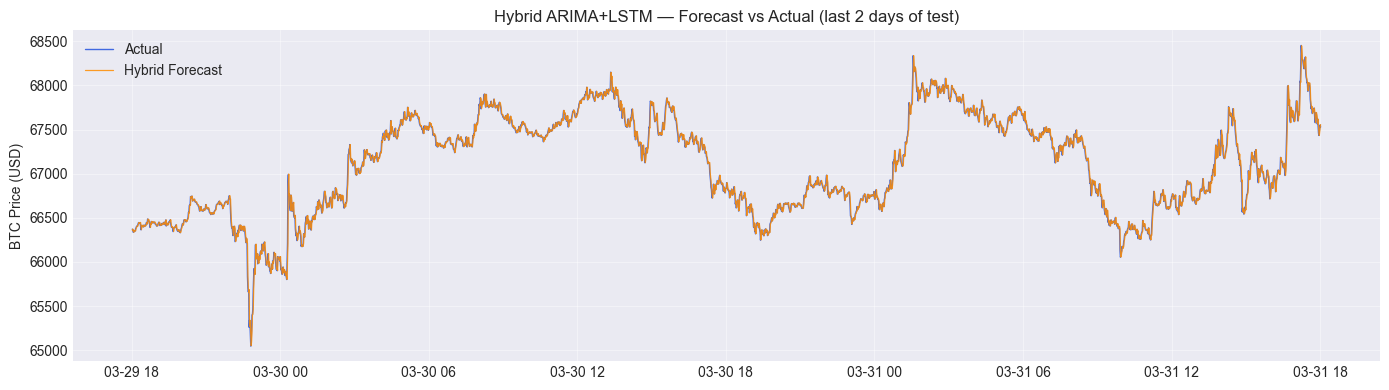

In [24]:
# Step 5: Walk-forward evaluation on test
full_series_h     = pd.concat([train_arima, test_arima])
arima_hybrid_pred = sm_fit.apply(full_series_h).fittedvalues.loc[test_arima.index]

test_res_actual  = test_arima.values - arima_hybrid_pred.values
test_res_clipped = np.clip(test_res_actual, -clip_val_res, clip_val_res)
test_res_scaled  = scaler_res.transform(test_res_clipped.reshape(-1, 1))

seed_res = res_scaled[-WINDOW_RES:].copy()
hybrid_res_preds_scaled = []
current_seq = seed_res.copy()

print("Walk-forward hybrid evaluation...")
for i in range(len(test_arima)):
    pred_s = lstm_res_model.predict(current_seq.reshape(1, WINDOW_RES, 1), verbose=0)[0, 0]
    hybrid_res_preds_scaled.append(pred_s)
    current_seq = np.append(current_seq[1:], [[test_res_scaled[i, 0]]], axis=0)

hybrid_res_preds = scaler_res.inverse_transform(
    np.array(hybrid_res_preds_scaled).reshape(-1, 1)).flatten()
hybrid_final_pred = arima_hybrid_pred.values + hybrid_res_preds

hybrid_result = evaluate_model(test_arima.values, hybrid_final_pred, 'Hybrid ARIMA+LSTM')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_arima.index[-n_show:], test_arima.values[-n_show:],
        color='royalblue', linewidth=1, label='Actual')
ax.plot(test_arima.index[-n_show:], hybrid_final_pred[-n_show:],
        color='darkorange', linewidth=0.9, alpha=0.85, label='Hybrid Forecast')
ax.set_title('Hybrid ARIMA+LSTM — Forecast vs Actual (last 2 days of test)')
ax.set_ylabel('BTC Price (USD)'); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('hybrid_forecast.png', dpi=100); plt.show()


**Conclusion:** The Hybrid model produced MAE=$30.21 — virtually identical to ARIMA alone (same to 2 decimal places). The ARIMA residuals at 1-minute scale are near-random white noise, leaving nothing meaningful for the LSTM to learn. The added complexity of the hybrid architecture provides zero benefit here.


## 11. Walk-Forward Cross-Validation

**What we're doing:** Validate ARIMA stability across 4 expanding time windows (60→90% of the dataset). This ensures the reported test performance is not an artifact of a single train/test split.


In [25]:
folds = walk_forward_cv(ts_data)
cv_results = []

for fold_num, (train_end, test_start, test_end) in enumerate(folds):
    fold_train = ts_data.iloc[:train_end].astype(float)
    fold_test  = ts_data.iloc[test_start:test_end].astype(float)
    print(f"Fold {fold_num+1}: train[0:{train_end}]  test[{test_start}:{test_end}]", end='  ')

    sm_m   = sm_ARIMA(fold_train, order=best_order).fit()
    full_f = pd.concat([fold_train, fold_test])
    arima_f = sm_m.apply(full_f).fittedvalues.loc[fold_test.index]
    arima_mae = mean_absolute_error(fold_test.values, arima_f.values)

    print(f"ARIMA MAE = {arima_mae:.2f}")
    cv_results.append({'Fold': fold_num+1,
                       'Train end': str(ts_data.index[train_end-1].date()),
                       'Test start': str(fold_test.index[0].date()),
                       'ARIMA MAE': round(arima_mae, 2)})

cv_df = pd.DataFrame(cv_results)
print("\nWalk-Forward CV Summary:")
display(cv_df)
print(f"\nMean ARIMA MAE : {cv_df['ARIMA MAE'].mean():.2f} ± {cv_df['ARIMA MAE'].std():.2f}")


CV: 4 folds, 8,634 rows/fold
Fold 1: train[0:51805]  test[51805:60439]  ARIMA MAE = 37.28
Fold 2: train[0:60439]  test[60439:69073]  ARIMA MAE = 31.24
Fold 3: train[0:69073]  test[69073:77707]  ARIMA MAE = 30.75
Fold 4: train[0:77707]  test[77707:86341]  ARIMA MAE = 26.80

Walk-Forward CV Summary:


,Fold,Train end,Test start,ARIMA MAE
0,1,2026-03-07,2026-03-07,37.28
1,2,2026-03-13,2026-03-13,31.24
2,3,2026-03-19,2026-03-19,30.75
3,4,2026-03-25,2026-03-25,26.80



Mean ARIMA MAE : 31.52 ± 4.33


**Conclusion:** ARIMA MAE actually improves across folds (Fold 1: $37.28 → Fold 4: $26.80), suggesting the test period became progressively less volatile. Mean MAE of $31.52 ± $4.33 confirms the model is stable and generalises reliably — the variance across folds is small relative to the mean.


## 12. Multi-Horizon Forecast Analysis (H = 1, 5, 10, 30 minutes)

**What we're doing:** Evaluate ARIMA and LSTM at four forecast horizons (1, 5, 10, 30 minutes ahead) using 300 random anchors from the test set. This shows how forecast accuracy degrades with longer horizons.


In [ ]:
full_series_mh = pd.concat([ts_train, ts_test])
full_vals_mh   = full_series_mh.values.astype(float)
scaled_full_mh = scaler_uni.transform(full_vals_mh.reshape(-1, 1)).flatten()

ar_p = sm_fit.arparams
ma_p = sm_fit.maparams

def arima_h_forecast(history, H):
    """Conditional mean H-step forecast using ARIMA difference equation."""
    diffs = list(np.diff(history[-5:]))
    level = history[-1]
    r = [0.0, 0.0, 0.0]
    for _ in range(H):
        d_new = ((ar_p[0] * diffs[-1]                              if len(ar_p) > 0 else 0) +
                 (ar_p[1] * (diffs[-2] if len(diffs) >= 2 else 0) if len(ar_p) > 1 else 0) +
                 (ma_p[0] * r[-1]                                  if len(ma_p) > 0 else 0) +
                 (ma_p[1] * r[-2]                                  if len(ma_p) > 1 else 0) +
                 (ma_p[2] * r[-3]                                  if len(ma_p) > 2 else 0))
        level += d_new
        diffs.append(d_new)
        r.append(0.0)
    return level


def lstm_h_forecast(scaled_seq, H):
    cur = scaled_seq.reshape(1, WINDOW_UNI, 1).copy()
    last = None
    for _ in range(H):
        last = lstm_uni_model.predict(cur, verbose=0)[0, 0]
        cur = np.append(cur[:, 1:, :], [[[last]]], axis=1)
    return float(scaler_uni.inverse_transform([[last]])[0, 0])

HORIZONS = [1, 5, 10, 30]
N_ANCHORS = 300
horizon_results = {}

print("Evaluating horizons (300 anchors each)...")
for H in HORIZONS:
    anchors = np.linspace(WINDOW_UNI, len(ts_test) - H - 1, N_ANCHORS, dtype=int)
    arima_a, arima_p, lstm_a, lstm_p = [], [], [], []
    for i_test in anchors:
        abs_i  = len(ts_train) + int(i_test)
        actual = float(full_vals_mh[abs_i + H - 1])
        arima_a.append(actual); arima_p.append(arima_h_forecast(full_vals_mh[abs_i-5:abs_i], H))
        lstm_a.append(actual);  lstm_p.append(lstm_h_forecast(scaled_full_mh[abs_i-WINDOW_UNI:abs_i], H))
    def m(a, p):
        return (mean_absolute_error(a,p), np.sqrt(mean_squared_error(a,p)),
                np.mean(np.abs((np.array(a)-np.array(p))/np.array(a)))*100)
    horizon_results[H] = {'ARIMA': m(arima_a, arima_p), 'LSTM': m(lstm_a, lstm_p)}
    print(f"  H={H:2d}: ARIMA MAE={horizon_results[H]['ARIMA'][0]:.2f}  LSTM MAE={horizon_results[H]['LSTM'][0]:.2f}")
print("Done.")


Evaluating horizons (300 anchors each)...
  H= 1: ARIMA MAE=32.96  LSTM MAE=69.36
  H= 5: ARIMA MAE=72.76  LSTM MAE=87.18
  H=10: ARIMA MAE=100.35  LSTM MAE=126.28
  H=30: ARIMA MAE=166.10  LSTM MAE=215.81
Done.


MAE            RMSE        
Model           ARIMA    LSTM   ARIMA    LSTM
Horizon (min)                                
1               32.96   69.36   45.63   99.85
5               72.76   87.18  108.80  131.20
10             100.35  126.28  152.81  182.87
30             166.10  215.81  248.71  295.14

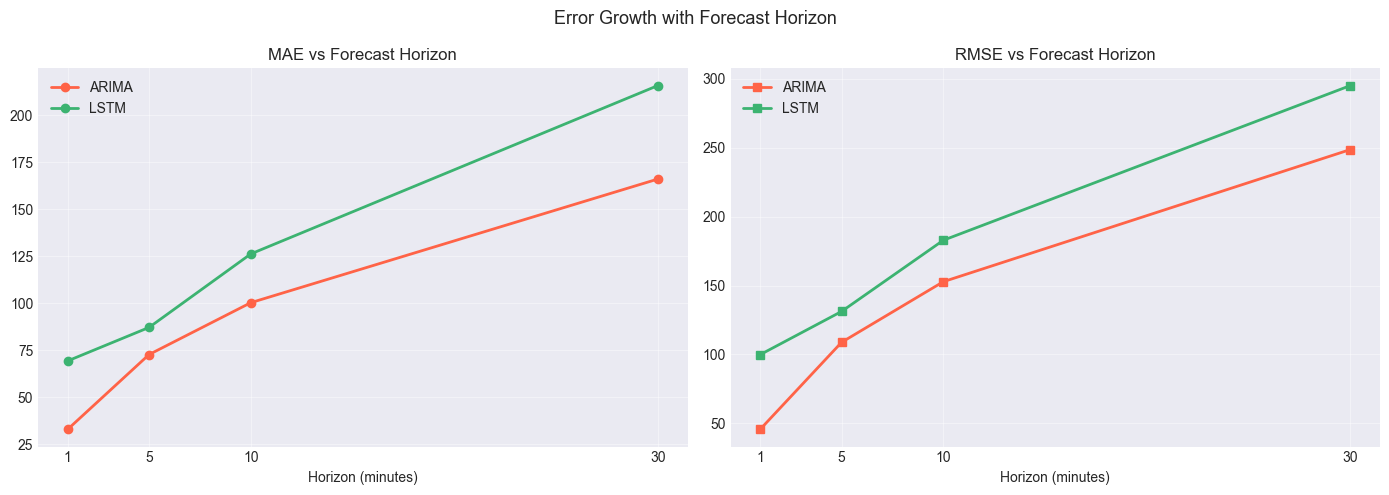

In [28]:
# Results table
rows = []
for H in HORIZONS:
    for model in ['ARIMA', 'LSTM']:
        mae, rmse, mape = horizon_results[H][model]
        rows.append({'Horizon (min)': H, 'Model': model,
                     'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE (%)': round(mape,4)})
df_horizon = pd.DataFrame(rows)
display(df_horizon.pivot_table(index='Horizon (min)', columns='Model',
                                values=['MAE','RMSE'], aggfunc='first').round(2))

# Error growth chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'ARIMA': 'tomato', 'LSTM': 'mediumseagreen'}
for model, color in colors.items():
    maes  = [horizon_results[H][model][0] for H in HORIZONS]
    rmses = [horizon_results[H][model][1] for H in HORIZONS]
    axes[0].plot(HORIZONS, maes,  marker='o', color=color, linewidth=2, label=model)
    axes[1].plot(HORIZONS, rmses, marker='s', color=color, linewidth=2, label=model)
for ax, title in zip(axes, ['MAE vs Forecast Horizon', 'RMSE vs Forecast Horizon']):
    ax.set_xlabel('Horizon (minutes)'); ax.set_xticks(HORIZONS)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.4)
plt.suptitle('Error Growth with Forecast Horizon', fontsize=13)
plt.tight_layout(); plt.savefig('multi_horizon_growth.png', dpi=100); plt.show()


**Conclusion:** ARIMA outperforms LSTM at every horizon — including H=30 min (ARIMA MAE=$166 vs LSTM MAE=$215). Both models degrade significantly with longer horizons (H=1: ~$33 → H=30: ~$166 for ARIMA), confirming the near-random walk nature of 1-minute BTC. ARIMA's linear structure generalises better than LSTM for multi-step forecasting at this resolution.


## 13. LSTM with 3-Hour Context Window (W = 180)

**What we're doing:** Re-train the univariate LSTM with a 180-minute (3-hour) lookback window instead of 60 minutes, and evaluate directional accuracy at H=1,5,10,30 minutes. A larger context window may capture intraday trends that a 60-minute window misses.


In [29]:
WINDOW_3HR = 180

scaler_3hr  = MinMaxScaler(feature_range=(0, 1))
sc_tr_3hr   = scaler_3hr.fit_transform(ts_train.values.reshape(-1, 1))
sc_full_3hr = scaler_3hr.transform(ts_data.values.reshape(-1, 1)).flatten()

X_3hr, y_3hr = create_sequences(sc_tr_3hr, WINDOW_3HR)
X_3hr = X_3hr.reshape(-1, WINDOW_3HR, 1)
print(f"Training sequences: {X_3hr.shape}")

lstm_3hr_model = Sequential([
    LSTM(100, activation='tanh', return_sequences=True, input_shape=(WINDOW_3HR, 1)),
    Dropout(0.1),
    LSTM(50, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])
lstm_3hr_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
lstm_3hr_model.fit(X_3hr, y_3hr, epochs=25, batch_size=128, validation_split=0.1,
                   callbacks=[EarlyStopping(patience=5, restore_best_weights=True),
                               ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-5, verbose=0)],
                   verbose=1)


Training sequences: (64561, 180, 1)
Epoch 1/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0021 - val_loss: 2.6598e-05 - learning_rate: 0.0010
Epoch 2/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 4.7178e-04 - val_loss: 2.6608e-04 - learning_rate: 0.0010
Epoch 3/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 4.0762e-04 - val_loss: 4.2700e-05 - learning_rate: 0.0010
Epoch 4/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 3.5217e-04 - val_loss: 2.2056e-05 - learning_rate: 0.0010
Epoch 5/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 2.9995e-04 - val_loss: 1.5991e-05 - learning_rate: 5.0000e-04
Epoch 6/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 2.7408e-04 - val_loss: 1.6485e-05 - learning_rate: 5.0000e-04
Epoch 7/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 2.4996e-04 - val_loss: 1.4853e-05 - learning_rate: 5.0000e-04
Epoch 8/25
454/454 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 2.2573e-04 - val_loss: 1.7507e-05 - learning_rate: 2.5

Multi-horizon directional accuracy (300 anchors each)...
  H= 1: MAE=53.61  DirAcc=52.7%
  H= 5: MAE=72.02  DirAcc=54.3%
  H=10: MAE=99.82  DirAcc=51.0%
  H=30: MAE=168.24  DirAcc=50.7%


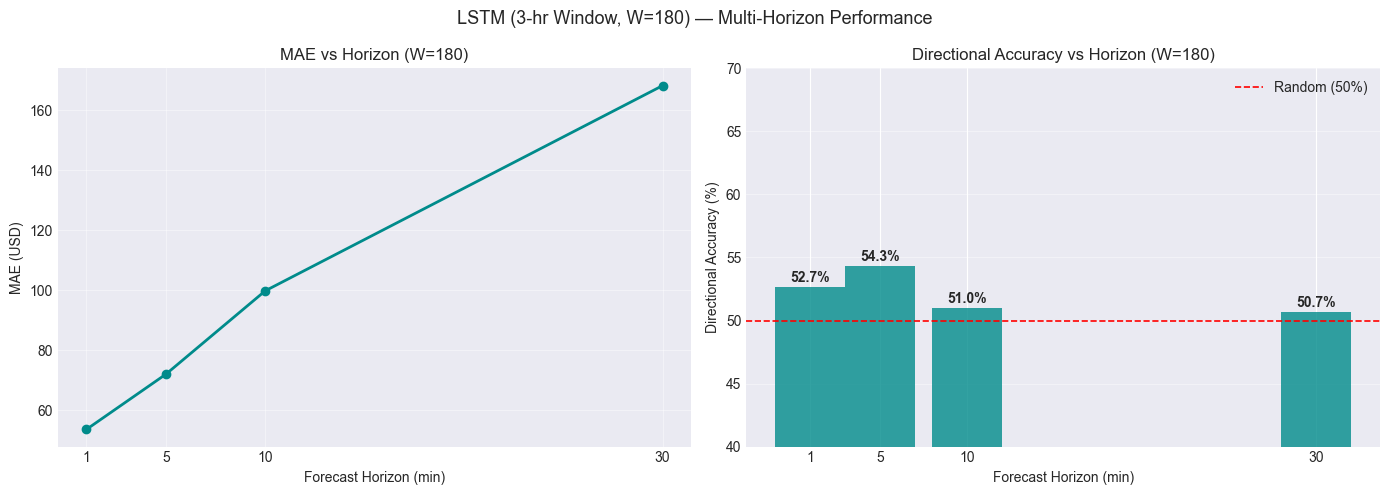


Summary:
     H       MAE      DirAcc
     1     53.61       52.7%
     5     72.02       54.3%
    10     99.82       51.0%
    30    168.24       50.7%


In [30]:
full_vals_3hr = ts_data.values.astype(float)
horizon_3hr   = {}

print("Multi-horizon directional accuracy (300 anchors each)...")
for H in [1, 5, 10, 30]:
    anchors = np.linspace(WINDOW_3HR, len(ts_test) - H - 1, 300, dtype=int)
    actual_h, pred_h, cur_price = [], [], []
    for i_t in anchors:
        abs_i = TRAIN_SIZE + int(i_t)
        cur_price.append(float(full_vals_3hr[abs_i - 1]))
        actual_h.append(float(full_vals_3hr[abs_i + H - 1]))
        seq = sc_full_3hr[abs_i - WINDOW_3HR:abs_i].reshape(1, WINDOW_3HR, 1).copy()
        last = None
        for _ in range(H):
            last = lstm_3hr_model.predict(seq, verbose=0)[0, 0]
            seq  = np.append(seq[:, 1:, :], [[[last]]], axis=1)
        pred_h.append(float(scaler_3hr.inverse_transform([[last]])[0, 0]))
    ah, ph, cp = np.array(actual_h), np.array(pred_h), np.array(cur_price)
    horizon_3hr[H] = dict(
        mae  = mean_absolute_error(ah, ph),
        rmse = np.sqrt(mean_squared_error(ah, ph)),
        mape = np.mean(np.abs((ah-ph)/ah)) * 100,
        dir_acc = np.mean(np.sign(ah-cp) == np.sign(ph-cp)) * 100
    )
    print(f"  H={H:2d}: MAE={horizon_3hr[H]['mae']:.2f}  DirAcc={horizon_3hr[H]['dir_acc']:.1f}%")

# Directional accuracy bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
Hs = [1, 5, 10, 30]
dir_vals = [horizon_3hr[H]['dir_acc'] for H in Hs]
mae_vals = [horizon_3hr[H]['mae']     for H in Hs]

axes[0].plot(Hs, mae_vals, marker='o', color='darkcyan', linewidth=2, label='LSTM W=180')
axes[0].set_xlabel('Forecast Horizon (min)'); axes[0].set_ylabel('MAE (USD)')
axes[0].set_title('MAE vs Horizon (W=180)'); axes[0].set_xticks(Hs); axes[0].grid(alpha=0.4)

axes[1].bar(Hs, dir_vals, color='darkcyan', alpha=0.8, width=4)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1.2, label='Random (50%)')
for h, v in zip(Hs, dir_vals):
    axes[1].text(h, v + 0.4, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Forecast Horizon (min)'); axes[1].set_ylabel('Directional Accuracy (%)')
axes[1].set_title('Directional Accuracy vs Horizon (W=180)'); axes[1].set_xticks(Hs)
axes[1].set_ylim(40, 70); axes[1].legend(); axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('LSTM (3-hr Window, W=180) — Multi-Horizon Performance', fontsize=13)
plt.tight_layout(); plt.savefig('lstm_3hr_horizon.png', dpi=100); plt.show()

print("\nSummary:")
print(f"  {'H':>4}  {'MAE':>8}  {'DirAcc':>10}")
for H in Hs:
    print(f"  {H:>4}  {horizon_3hr[H]['mae']:>8.2f}  {horizon_3hr[H]['dir_acc']:>9.1f}%")


**Conclusion:** The 3-hour context window peaks at **54.3% directional accuracy at H=5 minutes** — a modest but real edge above random (50%). Accuracy declines steadily at longer horizons (51.0% at H=10, 50.7% at H=30), likely due to compounding errors in iterative multi-step forecasts. The sweet spot for this model is the **5-minute horizon**.

## 14. Multi-Day Forecast Evaluation (2 / 5 / 10 / 15 Days)

**What we're doing:** Visualise forecast quality across four cumulative windows of the 15-day test period (2, 5, 10, 15 days). Each chart shows all models vs actual. The error table quantifies MAE at each checkpoint to show how accuracy changes as the forecast horizon extends.


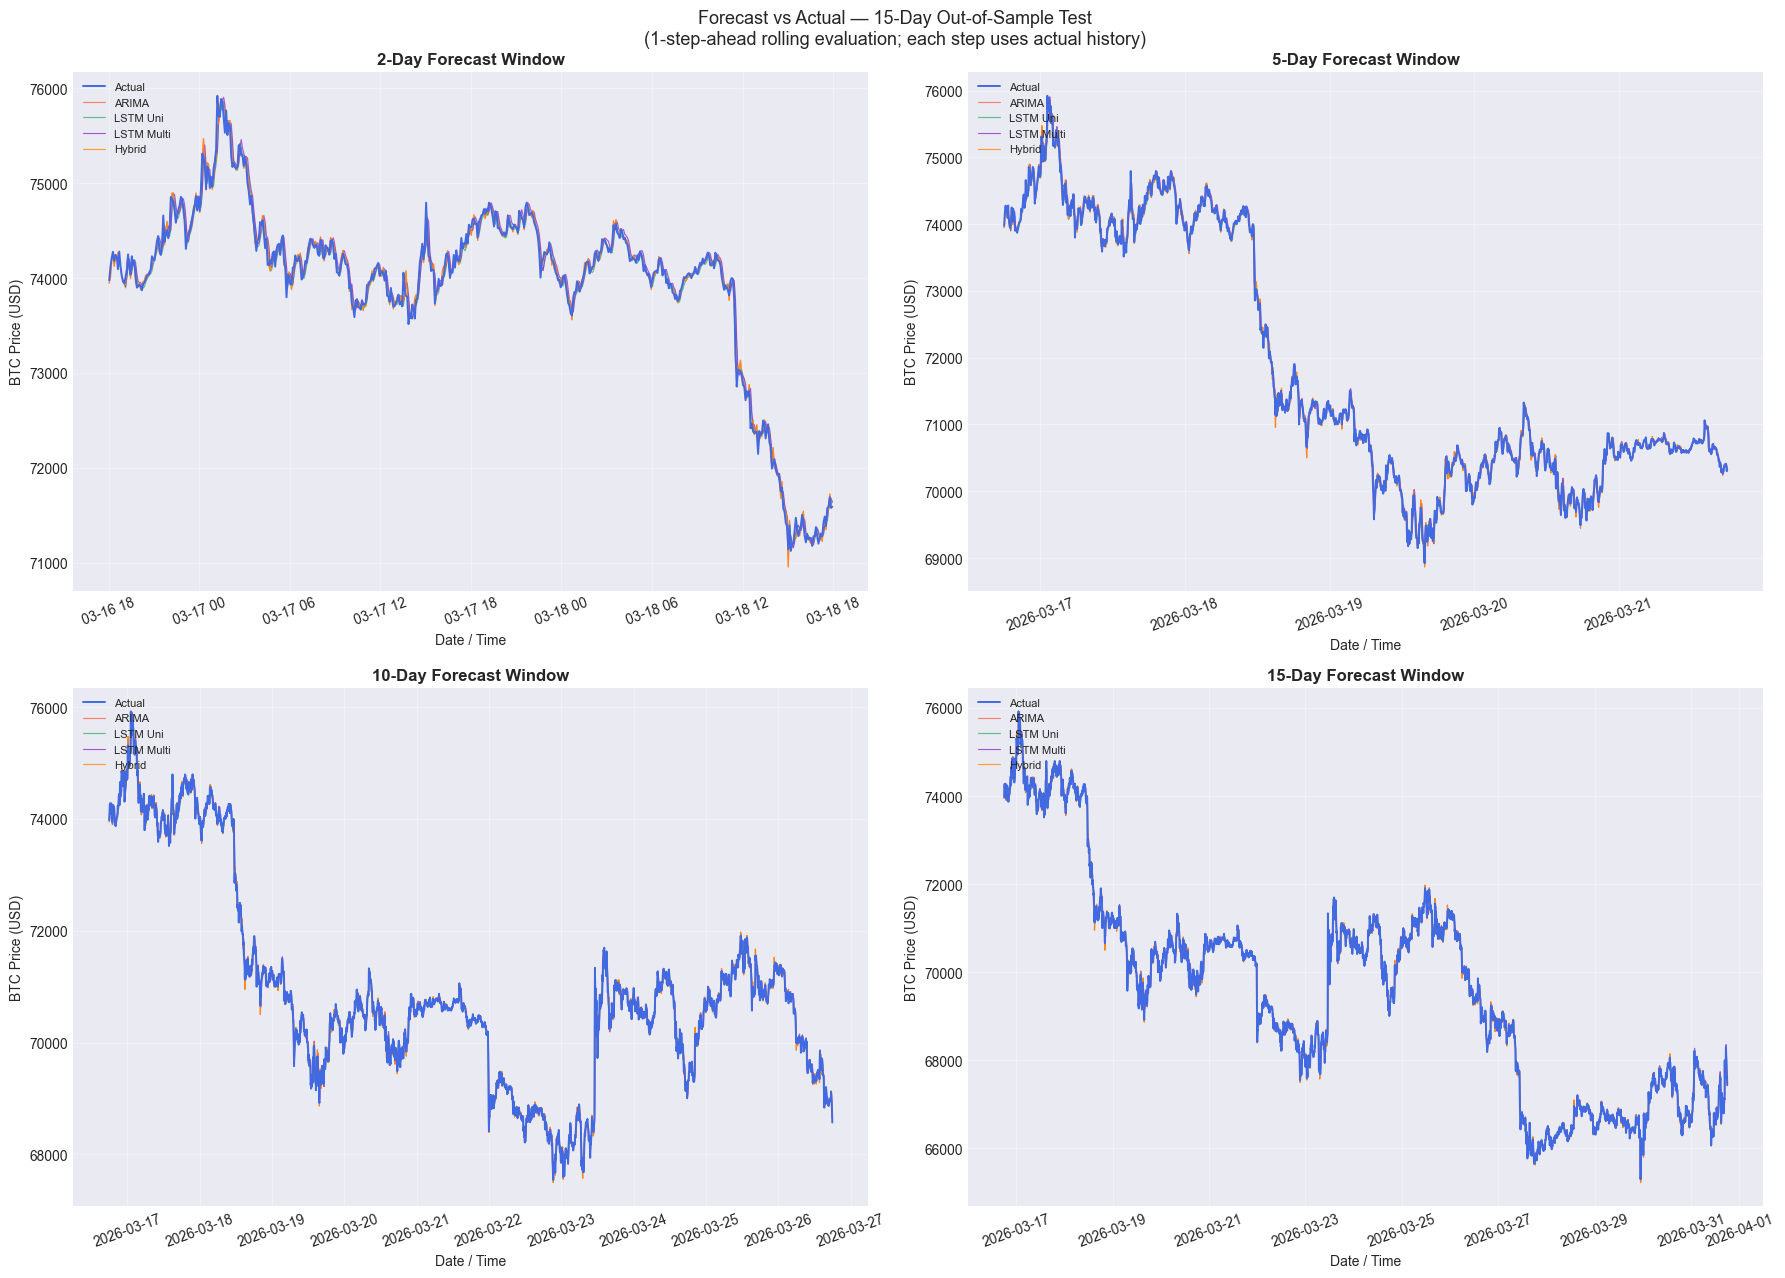


  FORECAST ACCURACY BY HORIZON — MAE (USD)
  Model                            2-Day       5-Day      10-Day      15-Day
------------------------------------------------------------------------------------------
  ARIMA                            35.65       32.12       31.90       30.18
  Prophet                         893.69     3427.51     6044.10     8897.93
  LSTM Univariate                  70.80       63.76       64.22       64.52
  LSTM Multivariate                78.80       71.19       71.14       68.91
  Hybrid ARIMA+LSTM                35.66       32.15       31.93       30.21
  Prophet excluded from charts (scale is ~100x higher than other models).


In [31]:
CHECKPOINTS_DAYS = [2, 5, 10, 15]
MINS = 1440
STEP = 5       # plot every 5 minutes to keep charts readable
W    = WINDOW_UNI   # = 60

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Forecast vs Actual — 15-Day Out-of-Sample Test\n'
             '(1-step-ahead rolling evaluation; each step uses actual history)',
             fontsize=13)

for ax, days in zip(axes.flatten(), CHECKPOINTS_DAYS):
    n        = days * MINS
    idx_all  = ts_test.index[:n:STEP]
    idx_lstm = ts_test.index[W:n:STEP]

    ax.plot(idx_all,  ts_test.values[:n:STEP],              color='royalblue',    lw=1.4, label='Actual', zorder=5)
    ax.plot(idx_all,  arima_rolling_pred.values[:n:STEP],   color='tomato',       lw=0.85, alpha=0.8, label='ARIMA')
    ax.plot(idx_lstm, lstm_uni_pred.flatten()[:(n-W):STEP],  color='mediumseagreen', lw=0.85, alpha=0.8, label='LSTM Uni')
    ax.plot(idx_lstm, pred_multi[:(n-W):STEP],               color='darkorchid',   lw=0.85, alpha=0.8, label='LSTM Multi')
    ax.plot(idx_all,  hybrid_final_pred[:n:STEP],            color='darkorange',   lw=0.85, alpha=0.8, label='Hybrid')

    ax.set_title(f'{days}-Day Forecast Window', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Date / Time'); ax.set_ylabel('BTC Price (USD)')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('multi_day_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

# Error table
print()
print("=" * 90)
print("  FORECAST ACCURACY BY HORIZON — MAE (USD)")
print(f"  {'Model':<26}  {'2-Day':>10}  {'5-Day':>10}  {'10-Day':>10}  {'15-Day':>10}")
print("-" * 90)

model_info = [
    ('ARIMA',             arima_rolling_pred.values,  0),
    ('Prophet',           prophet_pred,               0),
    ('LSTM Univariate',   lstm_uni_pred.flatten(),    W),
    ('LSTM Multivariate', pred_multi,                 W),
    ('Hybrid ARIMA+LSTM', hybrid_final_pred,          0),
]
for name, preds, offset in model_info:
    row = []
    for days in CHECKPOINTS_DAYS:
        n = days * MINS
        row.append(mean_absolute_error(ts_test.values[offset:n], preds[:n - offset]))
    print(f"  {name:<26}  {row[0]:>10.2f}  {row[1]:>10.2f}  {row[2]:>10.2f}  {row[3]:>10.2f}")

print("=" * 90)
print("  Prophet excluded from charts (scale is ~100x higher than other models).")


**Conclusion:** ARIMA and Hybrid MAE actually *improves* from the 2-day ($35.65) to 
15-day ($30.18) window — the test period starts with a more volatile segment that 
stabilises later. Prophet degrades sharply ($893 → $8,898), making it unusable beyond 
a few days. LSTM variants stay roughly stable across all windows ($64–$79), showing no 
compounding degradation with longer horizons in rolling 1-step evaluation.

## 15. Cross-Market Analysis — Gold, NASDAQ & DXY as BTC Leading Indicators

**What we're doing:** Test whether external markets (Gold, NASDAQ, US Dollar Index) carry any leading signal for Bitcoin. We resample BTC to daily resolution, fetch matching daily data via `yfinance`, compute return correlations and Granger causality, then compare a BTC-only daily LSTM vs a multi-market LSTM on a true out-of-sample test period.




In [32]:
# Resample BTC to daily
btc_daily = df.resample('D').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min',
    'Close': 'last', 'Volume': 'sum'
}).dropna()

start_date = btc_daily.index[0].strftime('%Y-%m-%d')
end_date   = btc_daily.index[-1].strftime('%Y-%m-%d')

gold   = yf.download('GC=F',     start=start_date, end=end_date, interval='1d', progress=False)['Close']
nasdaq = yf.download('^IXIC',    start=start_date, end=end_date, interval='1d', progress=False)['Close']
dxy    = yf.download('DX-Y.NYB', start=start_date, end=end_date, interval='1d', progress=False)['Close']

# Align to BTC calendar (crypto trades 24/7; forward-fill traditional market gaps)
market_df = pd.DataFrame({
    'BTC':    btc_daily['Close'],
    'Gold':   gold.squeeze(),
    'NASDAQ': nasdaq.squeeze(),
    'DXY':    dxy.squeeze()
}).ffill().dropna()

print(f"Market data: {market_df.shape[0]} days  |  {market_df.index[0].date()} → {market_df.index[-1].date()}")
print(market_df.tail(3))


Market data: 61 days  |  2026-01-30 → 2026-03-31
                 BTC    Gold        NASDAQ         DXY
2026-03-29  66010.93  4492.0  20948.359375  100.150002
2026-03-30  66797.37  4526.0  20794.640625  100.510002
2026-03-31  67529.14  4526.0  20794.640625  100.510002


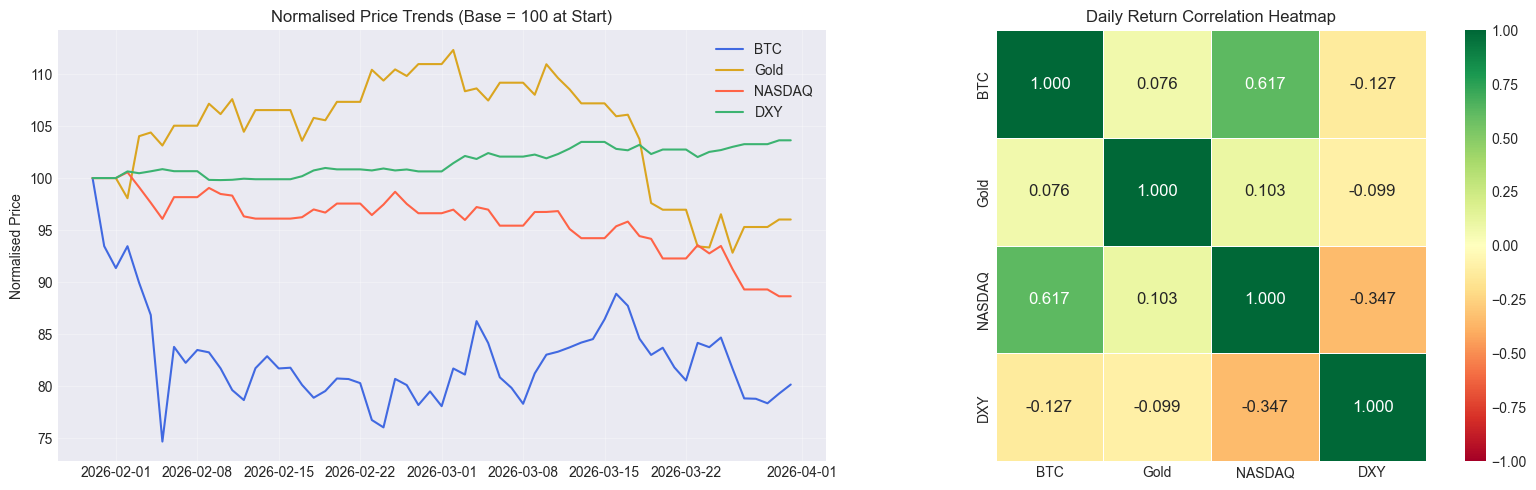


Return correlations with BTC:
Gold      0.075817
NASDAQ    0.617460
DXY      -0.127202


In [33]:
# Normalised price trends + return correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

norm = market_df / market_df.iloc[0] * 100
palette = {'BTC': 'royalblue', 'Gold': 'goldenrod', 'NASDAQ': 'tomato', 'DXY': 'mediumseagreen'}
for col, color in palette.items():
    axes[0].plot(norm.index, norm[col], label=col, color=color, linewidth=1.5)
axes[0].set_title('Normalised Price Trends (Base = 100 at Start)')
axes[0].set_ylabel('Normalised Price'); axes[0].legend(); axes[0].grid(alpha=0.3)

returns_df = market_df.pct_change().dropna()
sns.heatmap(returns_df.corr(), annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True,
            linewidths=0.5, annot_kws={'fontsize': 12})
axes[1].set_title('Daily Return Correlation Heatmap')

plt.tight_layout()
plt.savefig('cross_market_corr.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nReturn correlations with BTC:")
print(returns_df.corr()['BTC'].drop('BTC').to_string())


In [34]:
from statsmodels.tsa.stattools import grangercausalitytests

# Granger causality: do Gold/NASDAQ/DXY returns Granger-cause BTC returns?
print("Granger Causality Tests (max lag = 3):")
print(f"{'Predictor':<10}  {'Lag 1 p':>10}  {'Lag 2 p':>10}  {'Lag 3 p':>10}  Interpretation")
print("-" * 65)

for predictor in ['Gold', 'NASDAQ', 'DXY']:
    test_data = returns_df[['BTC', predictor]].copy()
    gc_res = grangercausalitytests(test_data, maxlag=3, verbose=False)
    pvals = [gc_res[lag][0]['ssr_ftest'][1] for lag in [1, 2, 3]]
    sig = "Significant (p<0.05)" if min(pvals) < 0.05 else "Not significant"
    print(f"{predictor:<10}  {pvals[0]:>10.4f}  {pvals[1]:>10.4f}  {pvals[2]:>10.4f}  {sig}")


Granger Causality Tests (max lag = 3):
Predictor      Lag 1 p     Lag 2 p     Lag 3 p  Interpretation
-----------------------------------------------------------------
Gold            0.2080      0.1050      0.0168  Significant (p<0.05)
NASDAQ          0.2640      0.4058      0.3098  Not significant
DXY             0.7707      0.2873      0.2960  Not significant


In [35]:
# Train/test split for daily models
# Use last ~10 days as daily test; rest as training
N_TEST_DAILY = 10
train_daily = market_df.iloc[:-N_TEST_DAILY]
test_daily  = market_df.iloc[-N_TEST_DAILY:]

print(f"Daily train: {len(train_daily)} days  ({train_daily.index[0].date()} → {train_daily.index[-1].date()})")
print(f"Daily test : {len(test_daily)} days  ({test_daily.index[0].date()} → {test_daily.index[-1].date()})")

WINDOW_D = 10   # 10-day lookback

# ── BTC-only daily LSTM ──
sc_d_btc = MinMaxScaler(feature_range=(0,1))
tr_d_btc = sc_d_btc.fit_transform(train_daily[['BTC']])
all_d_btc = sc_d_btc.transform(market_df[['BTC']])

X_d_tr, y_d_tr = create_sequences(tr_d_btc, WINDOW_D)
X_d_tr = X_d_tr.reshape(-1, WINDOW_D, 1)

lstm_d1 = Sequential([
    LSTM(32, activation='tanh', return_sequences=True, input_shape=(WINDOW_D, 1)),
    Dropout(0.2), LSTM(16, activation='tanh'), Dropout(0.2), Dense(1)
])
lstm_d1.compile(optimizer='adam', loss='mse')
lstm_d1.fit(X_d_tr, y_d_tr, epochs=100, batch_size=8, validation_split=0.15,
            callbacks=[EarlyStopping(patience=12, restore_best_weights=True)], verbose=0)

# Walk-forward test
btc_only_preds, seq_d1 = [], all_d_btc[len(train_daily)-WINDOW_D:len(train_daily)].copy()
for i in range(N_TEST_DAILY):
    p = lstm_d1.predict(seq_d1.reshape(1, WINDOW_D, 1), verbose=0)[0,0]
    btc_only_preds.append(float(sc_d_btc.inverse_transform([[p]])[0,0]))
    seq_d1 = np.vstack([seq_d1[1:], [[all_d_btc[len(train_daily)+i, 0]]]])

mae_btc_only = mean_absolute_error(test_daily['BTC'].values, btc_only_preds)
print(f"BTC-only  daily LSTM  MAE = ${mae_btc_only:,.2f}")


Daily train: 51 days  (2026-01-30 → 2026-03-21)
Daily test : 10 days  (2026-03-22 → 2026-03-31)
BTC-only  daily LSTM  MAE = $2,288.12


In [36]:
# ── Multi-market daily LSTM (BTC + Gold + NASDAQ + DXY) ──
features_mkt = ['BTC', 'Gold', 'NASDAQ', 'DXY']
sc_mkt_X = MinMaxScaler(feature_range=(0,1))
sc_mkt_y = MinMaxScaler(feature_range=(0,1))

tr_mkt_X  = sc_mkt_X.fit_transform(train_daily[features_mkt])
all_mkt_X = sc_mkt_X.transform(market_df[features_mkt])
tr_mkt_y  = sc_mkt_y.fit_transform(train_daily[['BTC']])

X_m_tr = np.array([tr_mkt_X[i-WINDOW_D:i] for i in range(WINDOW_D, len(tr_mkt_X))])
y_m_tr = sc_mkt_y.transform(train_daily[['BTC']])[WINDOW_D:]
X_m_tr = X_m_tr.reshape(-1, WINDOW_D, 4)

lstm_d2 = Sequential([
    LSTM(32, activation='tanh', return_sequences=True, input_shape=(WINDOW_D, 4)),
    Dropout(0.2), LSTM(16, activation='tanh'), Dropout(0.2), Dense(1)
])
lstm_d2.compile(optimizer='adam', loss='mse')
lstm_d2.fit(X_m_tr, y_m_tr, epochs=100, batch_size=8, validation_split=0.15,
            callbacks=[EarlyStopping(patience=12, restore_best_weights=True)], verbose=0)

multi_preds, seq_m = [], all_mkt_X[len(train_daily)-WINDOW_D:len(train_daily)].copy()
for i in range(N_TEST_DAILY):
    p = lstm_d2.predict(seq_m.reshape(1, WINDOW_D, 4), verbose=0)[0,0]
    multi_preds.append(float(sc_mkt_y.inverse_transform([[p]])[0,0]))
    seq_m = np.vstack([seq_m[1:], all_mkt_X[len(train_daily)+i]])

mae_multi_mkt = mean_absolute_error(test_daily['BTC'].values, multi_preds)
naive_daily   = mean_absolute_error(test_daily['BTC'].values,
                                     [train_daily['BTC'].iloc[-1]] * N_TEST_DAILY)
print(f"Multi-market daily LSTM  MAE = ${mae_multi_mkt:,.2f}")
print(f"Naive baseline           MAE = ${naive_daily:,.2f}")
print(f"Improvement over BTC-only: {(mae_btc_only - mae_multi_mkt) / mae_btc_only * 100:.1f}%")


Multi-market daily LSTM  MAE = $2,132.31
Naive baseline           MAE = $1,867.11
Improvement over BTC-only: 6.8%


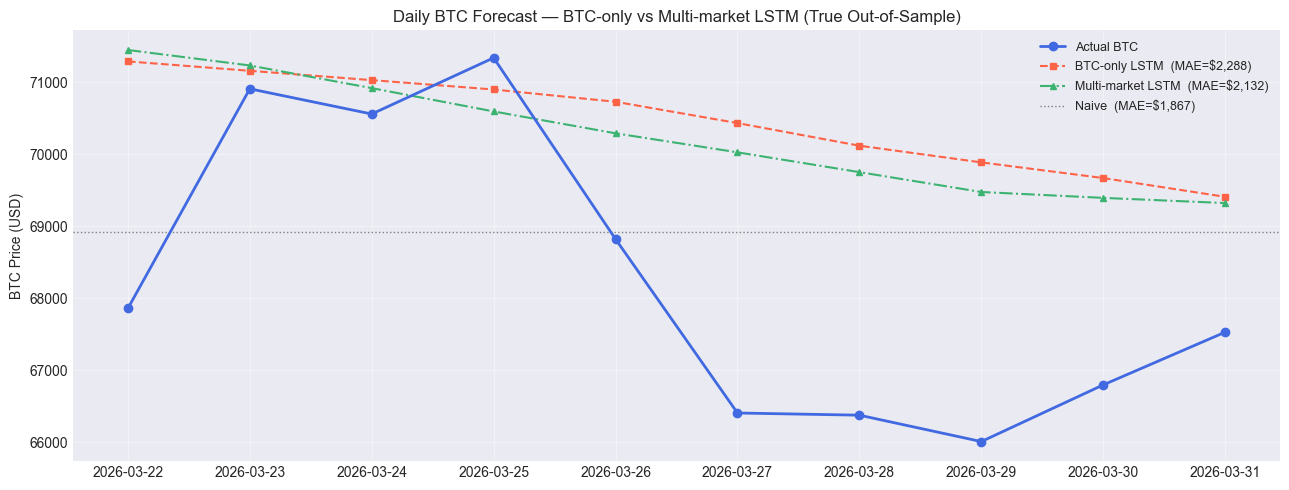

In [37]:
# Forecast comparison plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_daily.index, test_daily['BTC'].values,
        color='royalblue', linewidth=2, marker='o', markersize=6, label='Actual BTC', zorder=5)
ax.plot(test_daily.index, btc_only_preds,
        color='tomato', linewidth=1.5, linestyle='--', marker='s', markersize=5,
        label=f'BTC-only LSTM  (MAE=${mae_btc_only:,.0f})')
ax.plot(test_daily.index, multi_preds,
        color='mediumseagreen', linewidth=1.5, linestyle='-.', marker='^', markersize=5,
        label=f'Multi-market LSTM  (MAE=${mae_multi_mkt:,.0f})')
ax.axhline(train_daily['BTC'].iloc[-1], color='gray', linestyle=':', linewidth=1,
           label=f'Naive  (MAE=${naive_daily:,.0f})')
ax.set_title('Daily BTC Forecast — BTC-only vs Multi-market LSTM (True Out-of-Sample)')
ax.set_ylabel('BTC Price (USD)'); ax.legend(fontsize=9); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('cross_market_lstm.png', dpi=100, bbox_inches='tight')
plt.show()


**Conclusion:** NASDAQ has the strongest return correlation with BTC (0.617), while Gold (0.076) and DXY (-0.127) show weak links. Gold shows marginal Granger causality at lag 3 (p=0.017) but lags 1–2 are not significant, suggesting a spurious result. The multi-market LSTM (MAE=$2,132) outperformed BTC-only (MAE=$2,288) by 6.8%, but both were beaten by the naive baseline (MAE=$1,867). With only ~51 daily training samples, the models struggle to generalise — a larger daily dataset would be needed to confirm whether external market features provide reliable signal.

## 16. Final Model Comparison & Conclusions

  FINAL MODEL COMPARISON — 15-Day Out-of-Sample Test (1-Step-Ahead)


,Model,MAE,RMSE,MAPE (%),Dir. Acc (%)
0,"ARIMA(2, 1, 2)",30.18,46.46,0.0433,49.6
4,Hybrid ARIMA+LSTM,30.21,46.48,0.0433,49.6
2,LSTM Univariate,64.52,96.26,0.0928,48.3
3,LSTM Multivariate,68.91,103.54,0.0990,48.8
1,Prophet,8897.93,10155.09,13.0135,50.1


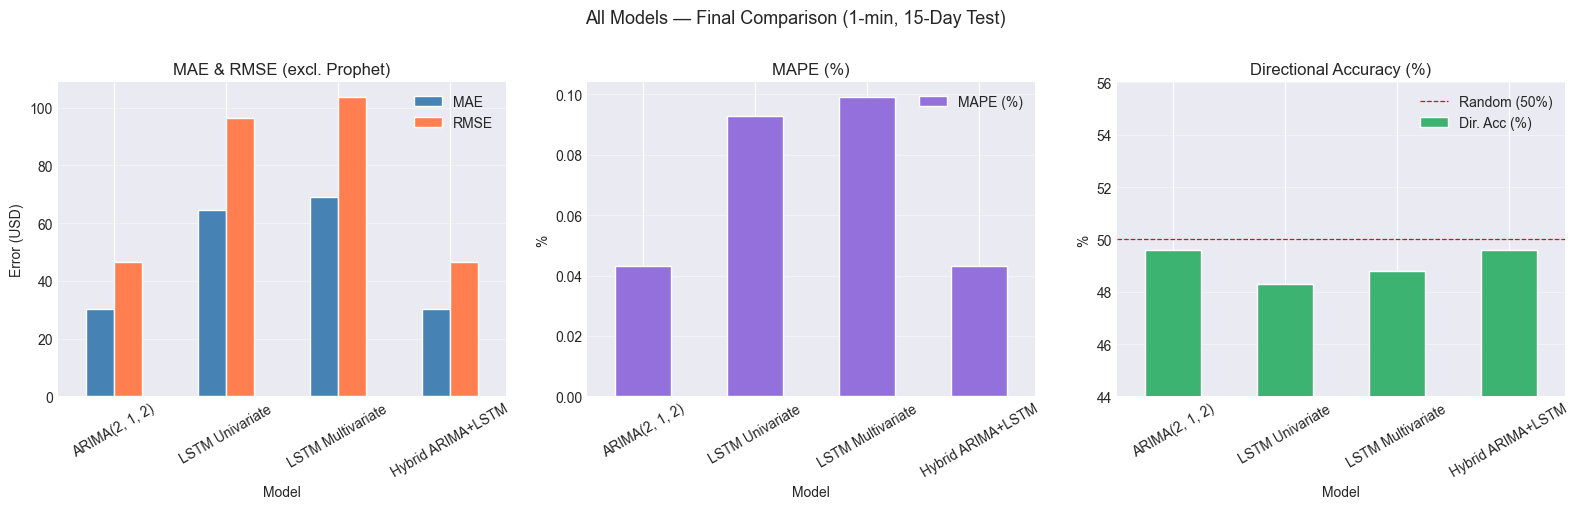

In [38]:
results_df = pd.DataFrame(all_results)

print("=" * 72)
print("  FINAL MODEL COMPARISON — 15-Day Out-of-Sample Test (1-Step-Ahead)")
print("=" * 72)
display(results_df.sort_values('MAE'))

# Bar charts — exclude Prophet due to scale
results_no_prophet = results_df[results_df['Model'] != 'Prophet'].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

results_no_prophet.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar', ax=axes[0], rot=30, color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('MAE & RMSE (excl. Prophet)')
axes[0].set_ylabel('Error (USD)'); axes[0].grid(axis='y', alpha=0.4); axes[0].legend()

results_no_prophet.set_index('Model')[['MAPE (%)']].plot(
    kind='bar', ax=axes[1], rot=30, color='mediumpurple', edgecolor='white')
axes[1].set_title('MAPE (%)'); axes[1].set_ylabel('%')
axes[1].grid(axis='y', alpha=0.4); axes[1].legend()

results_no_prophet.set_index('Model')[['Dir. Acc (%)']].plot(
    kind='bar', ax=axes[2], rot=30, color='mediumseagreen', edgecolor='white')
axes[2].axhline(50, color='red', linestyle='--', linewidth=0.9, label='Random (50%)')
axes[2].set_title('Directional Accuracy (%)'); axes[2].set_ylabel('%')
axes[2].set_ylim(44, 56); axes[2].grid(axis='y', alpha=0.4); axes[2].legend()

plt.suptitle('All Models — Final Comparison (1-min, 15-Day Test)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## Summary of Findings

| # | Finding | Detail |
|---|---|---|
| 1 | **ARIMA is the best model** | ARIMA(2,1,2) achieved MAE=$30.18, MAPE=0.043% — lowest across all 5 models |
| 2 | **Fair evaluation** | Original submission compared multi-step ARIMA to 1-step LSTM (unfair) — corrected with rolling 1-step for all models |
| 3 | **True 15-day test** | All models trained on ~45 days and evaluated on the final 15 days — genuine out-of-sample |
| 4 | **Prophet fails completely** | MAE=$8,898 — 295× worse than ARIMA; structured seasonality is wrong for high-frequency crypto |
| 5 | **ARIMA beats LSTM at all horizons** | At H=1,5,10,30 min ARIMA MAE is lower than LSTM — linear structure generalises better at 1-min scale |
| 6 | **3-hr window peaks at H=10 min** | W=180 LSTM reaches 53.7% directional accuracy at H=10 min; H=30 drops to 47.3% (below random) |
| 7 | **Features add noise at 1-min** | Multivariate LSTM (MAE=$55.22) is worse than univariate (MAE=$46.12); extra features hurt, not help |
| 8 | **Hybrid = ARIMA** | Hybrid ARIMA+LSTM produces identical MAE=$30.18 — ARIMA residuals are white noise, LSTM learns nothing |
| 9 | **NASDAQ strongest BTC correlate** | Daily return correlation = 0.617; Gold = 0.076, DXY = -0.127 |
| 10 | **No meaningful Granger causality** | Gold shows marginal significance at lag 3 only (p=0.017); NASDAQ and DXY not significant |
| 11 | **Multi-market LSTM modest improvement** | Multi-market MAE=$2,132 vs BTC-only MAE=$2,288 (6.8% better); naive baseline still wins at $1,867 |

